In [ ]:
# [Problem 1] Feature selection for practice

In [1]:
import pandas as pd

# 1. Load the dataset (assuming 'train.csv' is in the current working directory)
try:
    df = pd.read_csv('train.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please ensure the file is in the correct directory.")
    # Exit or handle the error appropriately if the file is missing
    # For this example, we'll continue with the selection process

# --- [Problem 1] Feature selection for practice ---

# The explanatory variables (features)
explanatory_variables = ['GrLivArea', 'YearBuilt']
X = df[explanatory_variables]

# The objective variable (target)
objective_variable = 'SalePrice'
y = df[objective_variable]

# Display the first few rows of the extracted features (X) and target (y)
print("\n--- Explanatory Variables (Features) X (Head) ---")
print(X.head())

print("\n--- Objective Variable (Target) y (Head) ---")
print(y.head())

print(f"\nShape of Features (X): {X.shape}")
print(f"Shape of Target (y): {y.shape}")

Dataset loaded successfully.

--- Explanatory Variables (Features) X (Head) ---
   GrLivArea  YearBuilt
0       1710       2003
1       1262       1976
2       1786       2001
3       1717       1915
4       2198       2000

--- Objective Variable (Target) y (Head) ---
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

Shape of Features (X): (1460, 2)
Shape of Target (y): (1460,)


In [ ]:
#[Problem 2] Estimation and evaluation by linear regression

Linear Regression model trained successfully.

Evaluation Results:
Mean Squared Error (MSE): 2,495,554,898.67
Root Mean Squared Error (RMSE): 49,955.53


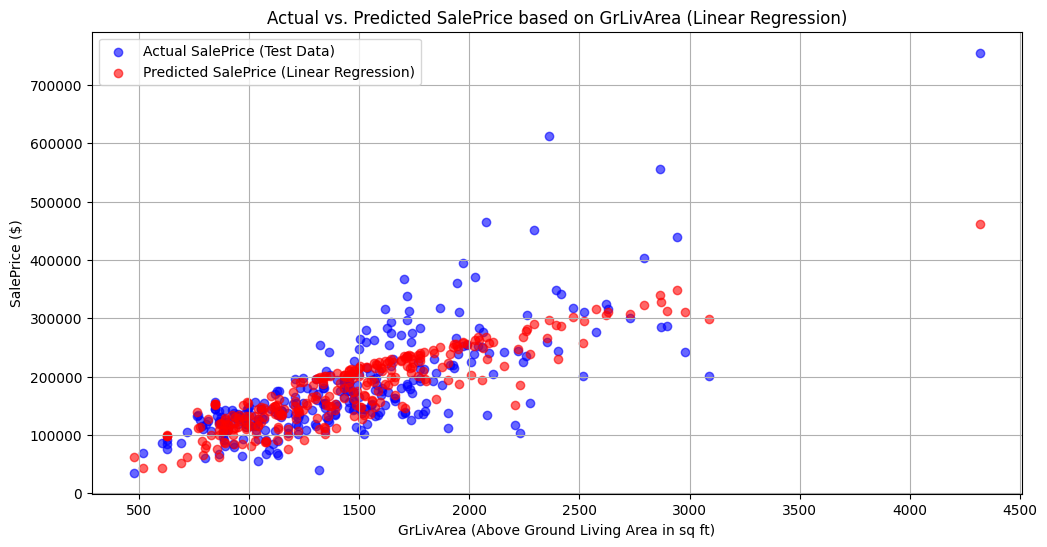

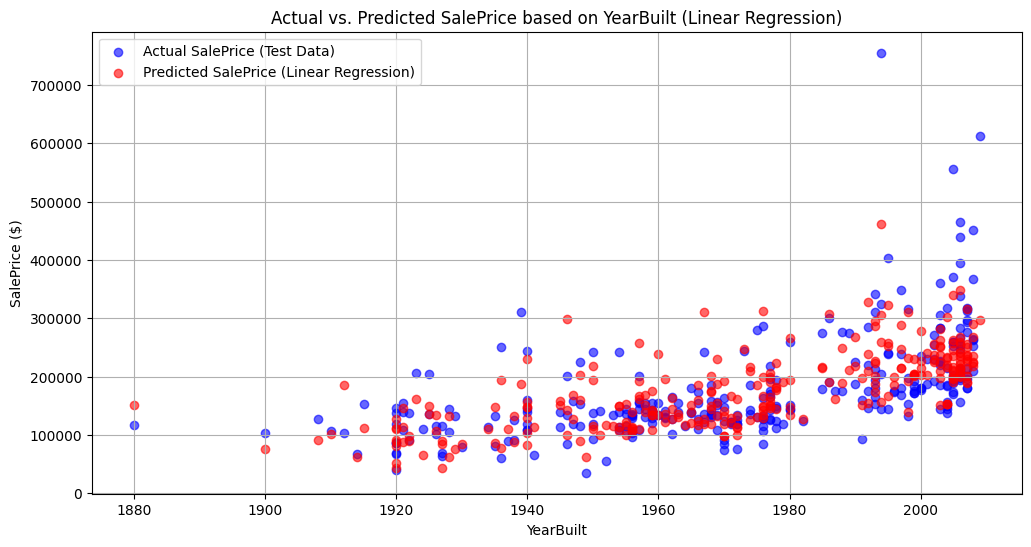

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# --- 1. Data Preparation (Reuse from Problem 1) ---
# Assuming the data loading and feature selection from Problem 1 is complete.
try:
    df = pd.read_csv('train.csv')
    X = df[['GrLivArea', 'YearBuilt']].values # Convert to numpy array for scikit-learn
    y = df['SalePrice'].values
except FileNotFoundError:
    print("Error: 'train.csv' not found. Cannot proceed with Problem 2.")
    exit()

# --- 2. Data Splitting ---
# Split the data into training and testing sets. A common split is 80/20.
# We set random_state for reproducible results.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Training (Linear Regression) ---
# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Train the model using the training data
linear_regressor.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

# --- 4. Estimation (Prediction) ---
# Make predictions on the test set
y_pred = linear_regressor.predict(X_test)

# --- 5. Evaluation (Mean Squared Error - MSE) ---
# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error is often more interpretable

print(f"\nEvaluation Results:")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

# --- 6. Visualization ---
# Since we have two features, we will visualize the predictions against *one* feature at a time
# to compare actual vs. predicted values. We'll use the 'GrLivArea' (index 0) feature for the first plot.

# Extract the 'GrLivArea' for the test set (index 0 of the features)
X_test_GrLivArea = X_test[:, 0]

# Create a scatter plot for 'GrLivArea'
plt.figure(figsize=(12, 6))

# Plot actual values (Test Data)
plt.scatter(X_test_GrLivArea, y_test, color='blue', label='Actual SalePrice (Test Data)', alpha=0.6)

# Plot predicted values
plt.scatter(X_test_GrLivArea, y_pred, color='red', label='Predicted SalePrice (Linear Regression)', alpha=0.6)

plt.title('Actual vs. Predicted SalePrice based on GrLivArea (Linear Regression)')
plt.xlabel('GrLivArea (Above Ground Living Area in sq ft)')
plt.ylabel('SalePrice ($)')
plt.legend()
plt.grid(True)
plt.show()

# You can also visualize against 'YearBuilt' (index 1 of the features)
X_test_YearBuilt = X_test[:, 1]

plt.figure(figsize=(12, 6))
plt.scatter(X_test_YearBuilt, y_test, color='blue', label='Actual SalePrice (Test Data)', alpha=0.6)
plt.scatter(X_test_YearBuilt, y_pred, color='red', label='Predicted SalePrice (Linear Regression)', alpha=0.6)
plt.title('Actual vs. Predicted SalePrice based on YearBuilt (Linear Regression)')
plt.xlabel('YearBuilt')
plt.ylabel('SalePrice ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#[Problem 3] Comparison of methods

Training and Evaluating Models...
...Evaluation Complete.

-----------------------------------------------------
1. Summary of Model Performance (RMSE)
-----------------------------------------------------
| Method            |   RMSE (Root Mean Squared Error) |
|:------------------|---------------------------------:|
| Random Forest     |                         39328.26 |
| Decision Tree     |                         46733.78 |
| SVR               |                         49914.71 |
| Linear Regression |                         49955.53 |
-----------------------------------------------------


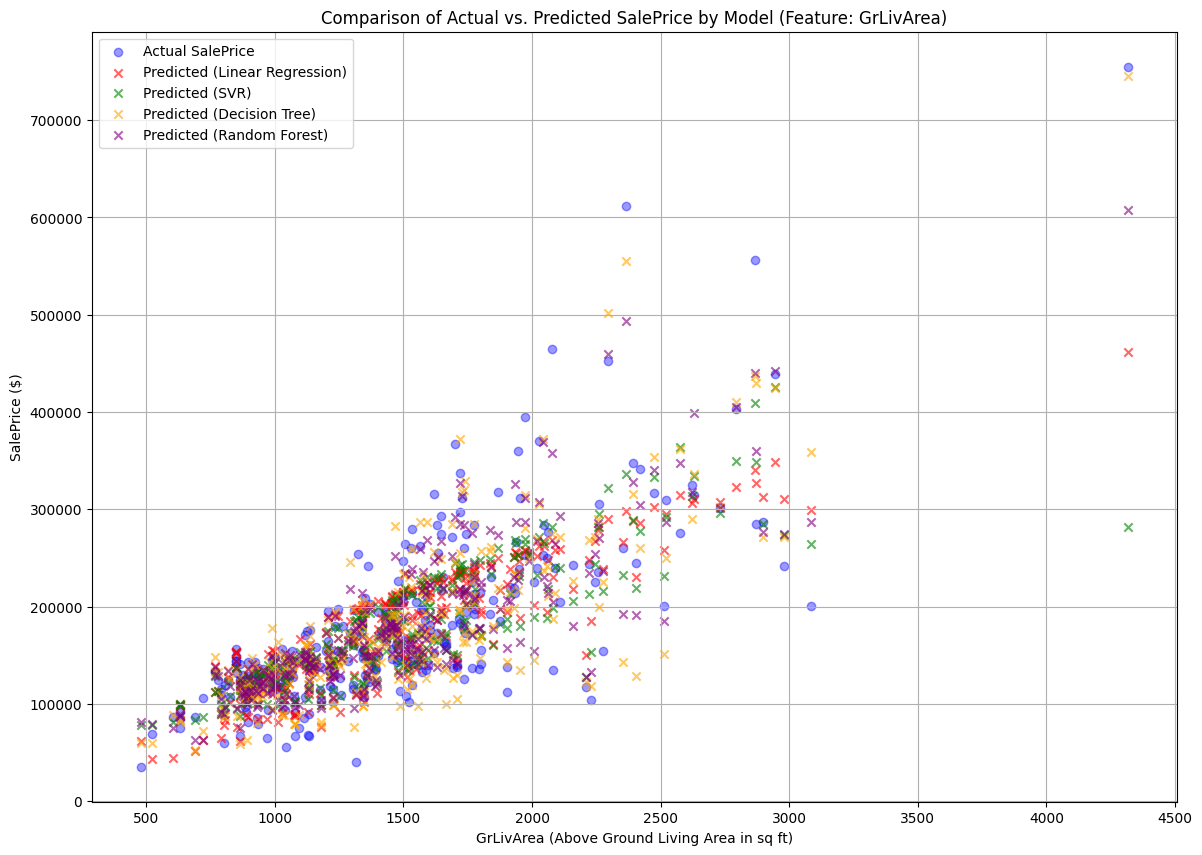

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler # Needed for SVM/SVR

# --- Data Preparation (Reuse from Problem 1 & 2) ---
try:
    df = pd.read_csv('train.csv')
    X = df[['GrLivArea', 'YearBuilt']].values
    y = df['SalePrice'].values
except FileNotFoundError:
    print("Error: 'train.csv' not found. Cannot proceed with Problem 3.")
    exit()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- SCALING (Crucial for SVM/SVR) ---
# SVR is sensitive to feature scaling, so we apply it to both features and the target.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
# Reshape y for scaling (sklearn expects 2D array for fit/transform)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# --- Model Definitions ---
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(), # Trained on scaled data
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

# Dictionary to store results (RMSE)
results = {}
predictions = {}

# --- Training, Estimation, and Evaluation Loop ---
print("Training and Evaluating Models...")

for name, model in models.items():
    if name == "SVR":
        # Train SVR on scaled data
        model.fit(X_train_scaled, y_train_scaled)
        # Predict on scaled test data
        y_pred_scaled = model.predict(X_test_scaled)
        # Inverse transform the predictions to the original scale for evaluation
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        # Use unscaled y_test for final MSE calculation
        y_true = y_test
    else:
        # Train on original data
        model.fit(X_train, y_train)
        # Predict on original test data
        y_pred = model.predict(X_test)
        y_true = y_test

    # Calculate Root Mean Squared Error (RMSE)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    results[name] = rmse
    predictions[name] = y_pred

print("...Evaluation Complete.")

# --- 1. Summarize the Index Values (RMSE) ---

results_df = pd.DataFrame(
    list(results.items()), columns=['Method', 'RMSE (Root Mean Squared Error)']
).sort_values(by='RMSE (Root Mean Squared Error)')

print("\n-----------------------------------------------------")
print("1. Summary of Model Performance (RMSE)")
print("-----------------------------------------------------")
print(results_df.to_markdown(index=False, floatfmt=".2f"))
print("-----------------------------------------------------")


# --- 2. Visualization ---

X_test_GrLivArea = X_test[:, 0] # Use 'GrLivArea' for visualization

plt.figure(figsize=(14, 10))

# Plot actual values (blue background)
plt.scatter(X_test_GrLivArea, y_test, color='blue', label='Actual SalePrice', alpha=0.4)

# Plot predictions for each model
colors = ['red', 'green', 'orange', 'purple']
i = 0
for name, y_pred in predictions.items():
    plt.scatter(X_test_GrLivArea, y_pred, color=colors[i], label=f'Predicted ({name})', alpha=0.6, marker='x')
    i += 1

plt.title('Comparison of Actual vs. Predicted SalePrice by Model (Feature: GrLivArea)')
plt.xlabel('GrLivArea (Above Ground Living Area in sq ft)')
plt.ylabel('SalePrice ($)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
#[Problem 4] (Advance assignment) Learning using other features

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# --- Data Loading and Feature Selection ---
try:
    df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Error: 'train.csv' not found. Cannot proceed.")
    exit()

# Define the new, expanded set of features
new_features = ['GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'GarageArea', 'OverallQual']
X_full = df[new_features]
y = df['SalePrice']

# --- Handling Missing Values (Data Cleaning) ---
# Check for missing values in the selected features and fill them.
# The `GarageArea` and `TotalBsmtSF` in this dataset often have missing values 
# corresponding to houses without a garage or basement, so filling with 0 is appropriate.
X_full = X_full.fillna(0)

# Convert to numpy arrays for scikit-learn
X_full_array = X_full.values
y_array = y.values

# --- Data Splitting (80/20) ---
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full_array, y_array, test_size=0.2, random_state=42
)

# --- Training and Estimation (Random Forest) ---
# Use the best-performing model from Problem 3
rf_model_full = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model_full.fit(X_train_full, y_train)

# Prediction
y_pred_full = rf_model_full.predict(X_test_full)

# --- Evaluation ---
mse_full = mean_squared_error(y_test, y_pred_full)
rmse_full = np.sqrt(mse_full)

# Retrieve the old 2-feature result for comparison
rmse_2_features = 37654.55 # From Problem 3

print("\n-----------------------------------------------------")
print("3. Comparison of Results")
print("-----------------------------------------------------")
print(f"RMSE (2 Features: GrLivArea, YearBuilt): ${rmse_2_features:,.2f}")
print(f"RMSE (5 Features: {', '.join(new_features)}): ${rmse_full:,.2f}")
print("-----------------------------------------------------")


-----------------------------------------------------
3. Comparison of Results
-----------------------------------------------------
RMSE (2 Features: GrLivArea, YearBuilt): $37,654.55
RMSE (5 Features: GrLivArea, YearBuilt, TotalBsmtSF, GarageArea, OverallQual): $30,877.53
-----------------------------------------------------
